## Principal Component Analysis

In [1]:
%run load_data.py

In [3]:
%whos DataFrame

Variable    Type         Data/Info
----------------------------------
X           DataFrame         Fresh   Milk  Grocer<...>n\n[440 rows x 6 columns]
Z           DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
Z_bc        DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
Z_bc_rmo    DataFrame            Fresh      Milk  <...>n\n[438 rows x 6 columns]
Z_log       DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
Z_log_rmo   DataFrame            Fresh      Milk  <...>n\n[435 rows x 6 columns]
boxcox_X    DataFrame             Fresh       Milk<...>n\n[440 rows x 6 columns]
log_X       DataFrame             Fresh      Milk <...>n\n[440 rows x 6 columns]


In [4]:
pca_box_cox = PCA()
pca_box_cox.fit(Z_bc_rmo)

PCA()

<Axes: >

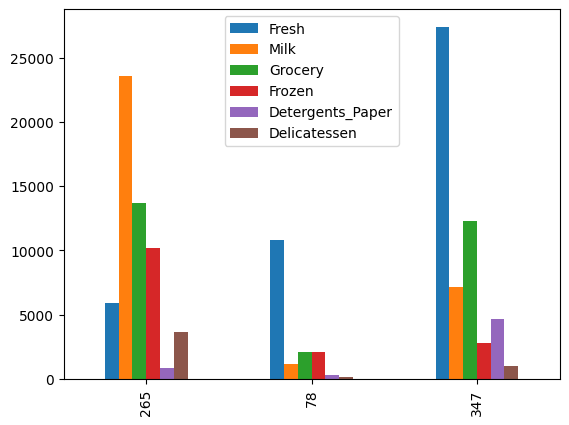

In [5]:
np.random.seed(42)
sample = X.sample(3)
sample.plot(kind='bar')

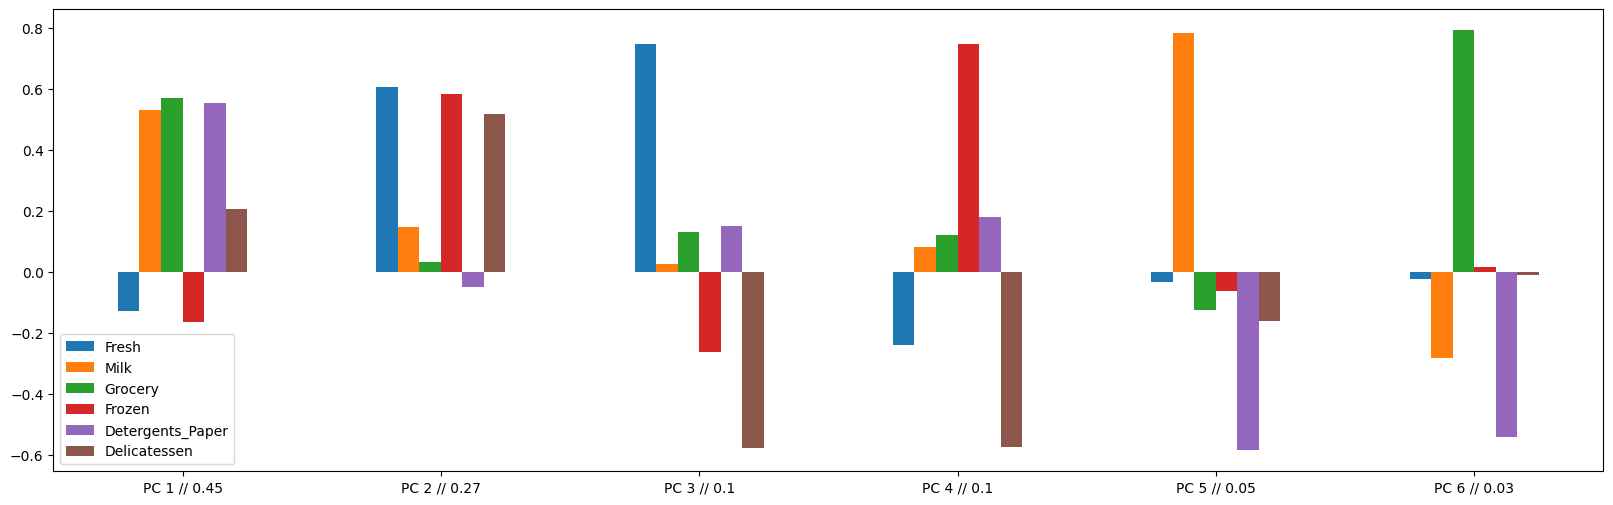

In [6]:
principal_component_loadings_box_cox = \
 pd.DataFrame(pca_box_cox.components_, 
 columns=Z_bc_rmo.columns)

explained_variance_ratio_box_cox = pca_box_cox.explained_variance_ratio_
pca_labels_box_cox = ['PC ' + str(i+1) +' // ' + str(round(ratio,2)) for i, ratio in enumerate(explained_variance_ratio_box_cox)]

ax = principal_component_loadings_box_cox.plot(kind='bar', figsize=(20,6), rot=0)
ax.set_xticklabels(pca_labels_box_cox);

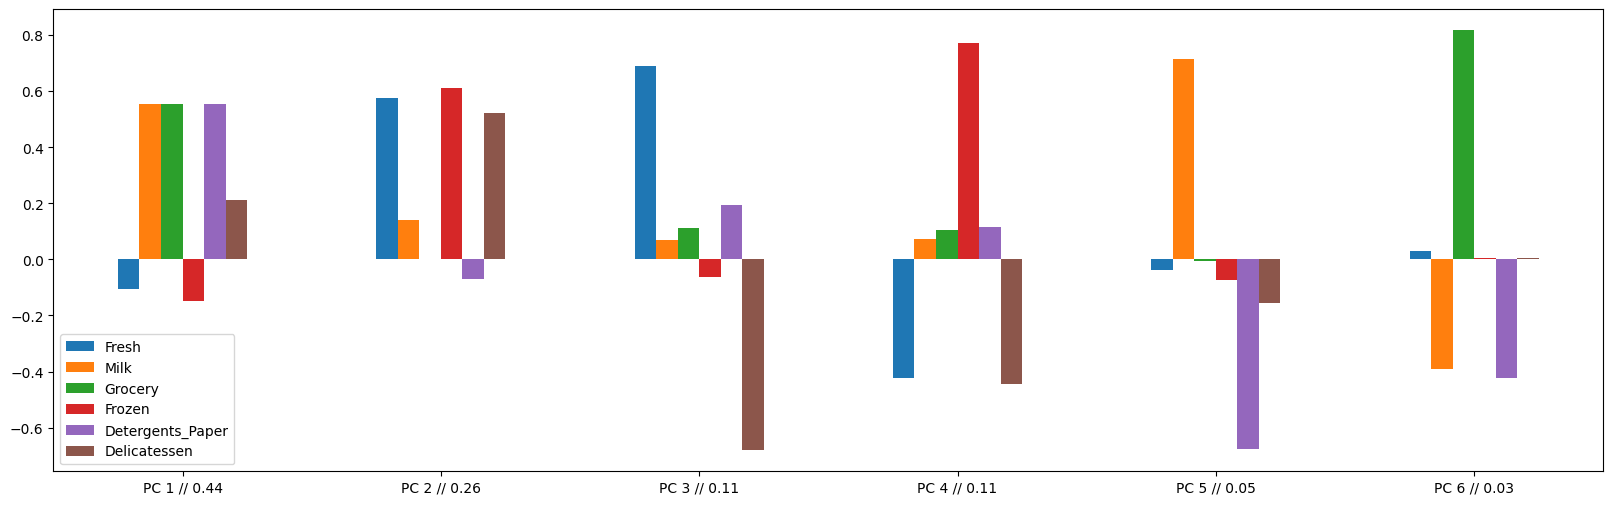

In [7]:
pca_log = PCA()
pca_log.fit(Z_log_rmo)

principal_component_loadings_log = pd.DataFrame(pca_log.components_, 
                                                columns=Z_log_rmo.columns)


explained_variance_ratio_log = pca_log.explained_variance_ratio_
pca_labels_log = ['PC ' + str(i+1) +' // ' + str(round(ratio,2)) for i, ratio in enumerate(explained_variance_ratio_log)]

ax = principal_component_loadings_log.plot(kind='bar', figsize=(20,6), rot=0)
ax.set_xticklabels(pca_labels_log);

In [8]:
pca_orig = PCA()
pca_orig.fit(X)
pca_scaled = PCA()
pca_scaled.fit(Z)

PCA()

In [9]:
principal_component_loadings_orig = pd.DataFrame(pca_orig.components_, 
                                                 columns=X.columns)
principal_component_loadings_scaled = pd.DataFrame(pca_scaled.components_, 
                                                   columns=Z.columns)

In [10]:
explained_variance_ratio_orig = pca_orig.explained_variance_ratio_
explained_variance_ratio_scaled = pca_scaled.explained_variance_ratio_
pca_labels_orig = ['PC ' + str(i+1) +' // ' + str(round(ratio,2)) for i, ratio in enumerate(explained_variance_ratio_orig)]
pca_labels_scaled = ['PC ' + str(i+1) +' // ' + str(round(ratio,2)) for i, ratio in enumerate(explained_variance_ratio_scaled)]

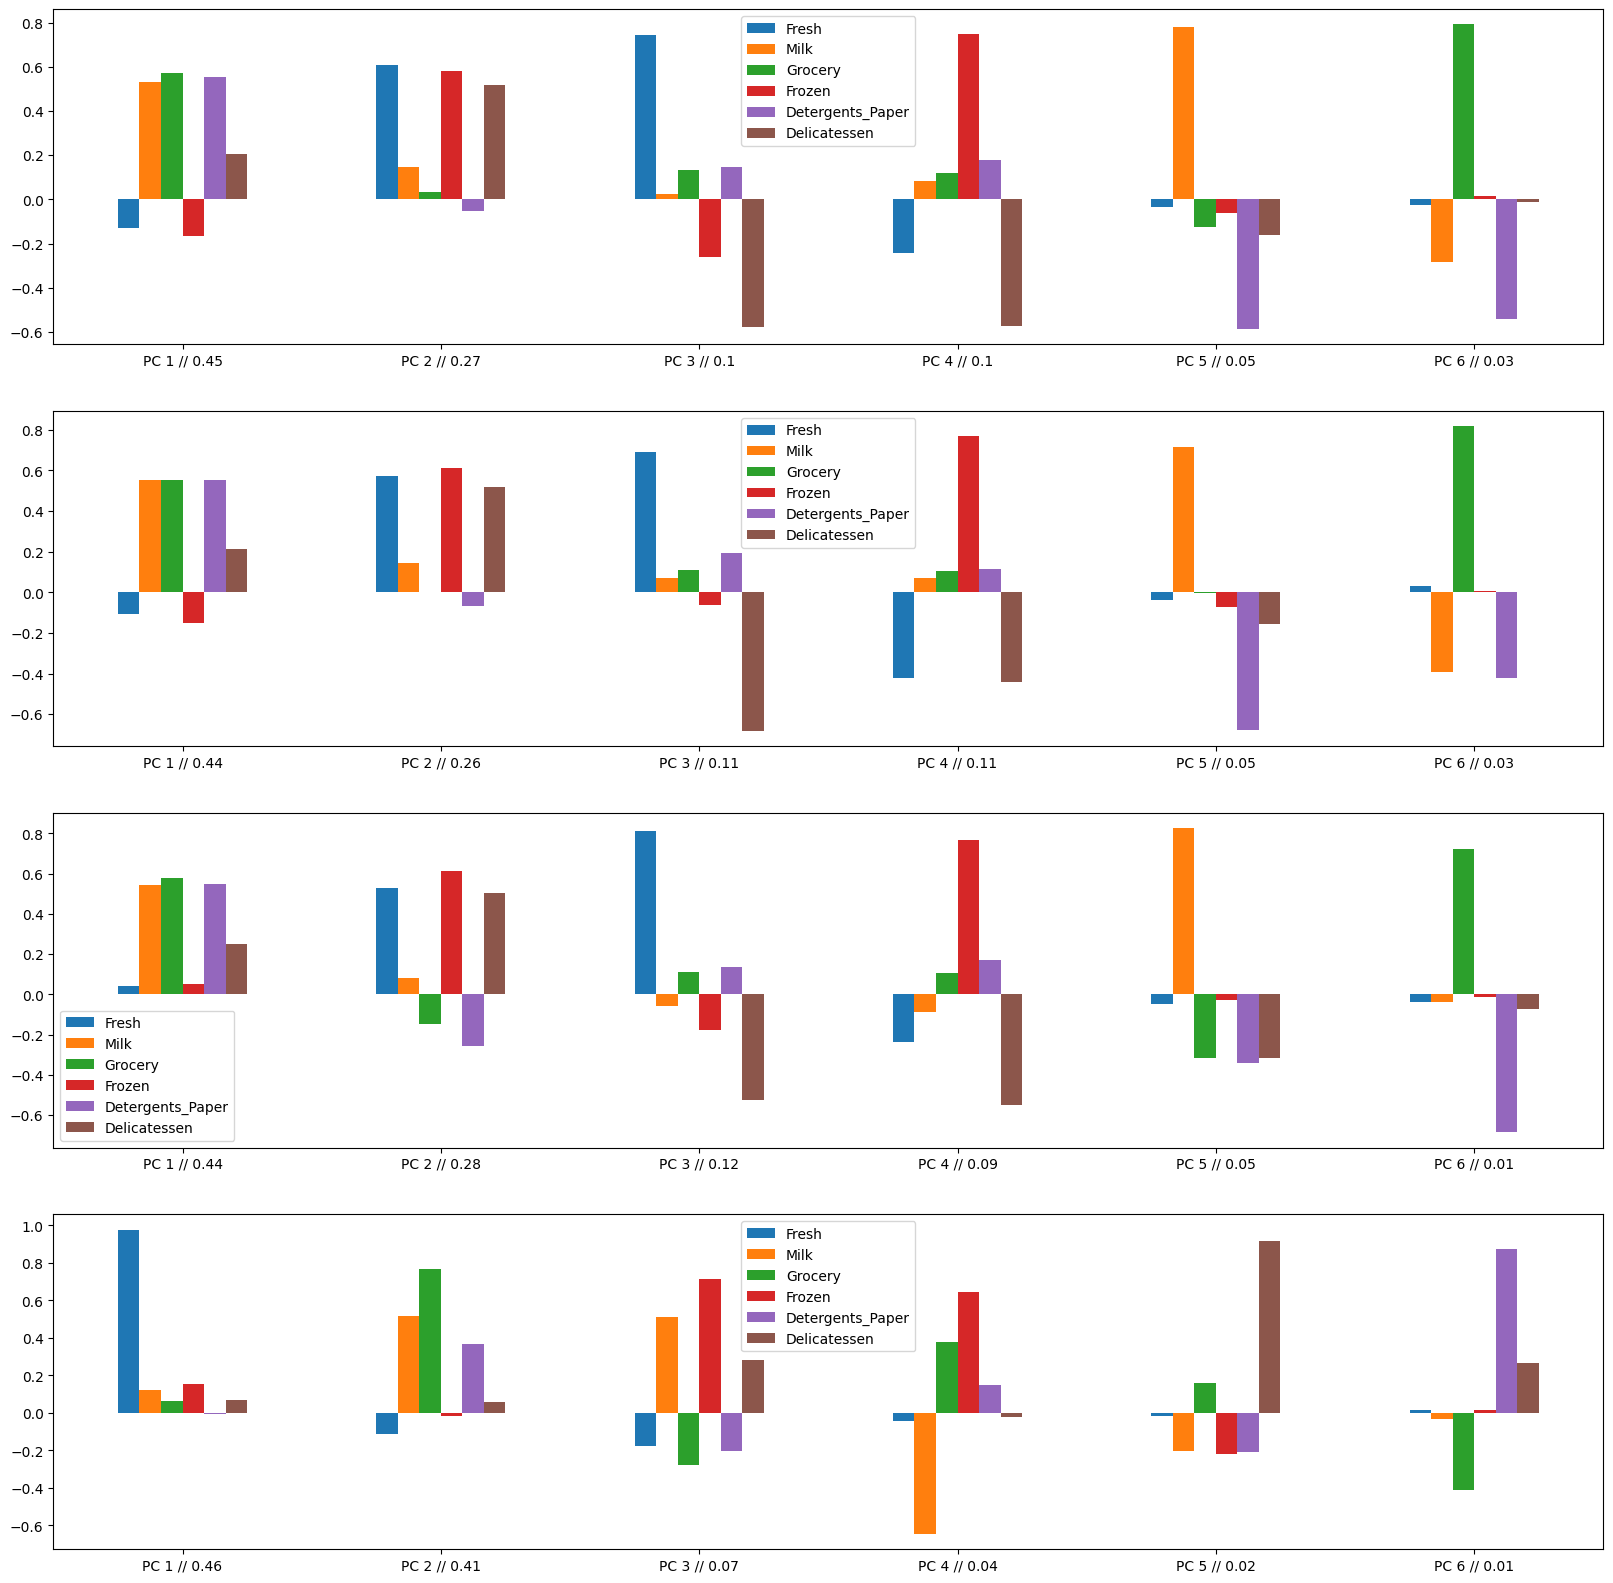

In [11]:
_, ax = plt.subplots(4,1,figsize=(20,20))
principal_component_loadings_box_cox.plot(kind='bar', rot=0, ax=ax[0])
ax[0].set_xticklabels(pca_labels_box_cox)
principal_component_loadings_log.plot(kind='bar', rot=0, ax=ax[1])
ax[1].set_xticklabels(pca_labels_log)
principal_component_loadings_scaled.plot(kind='bar', rot=0, ax=ax[2])
ax[2].set_xticklabels(pca_labels_scaled)
principal_component_loadings_orig.plot(kind='bar', rot=0, ax=ax[3])
ax[3].set_xticklabels(pca_labels_orig);

#### Scree Plot

Look for "the bend". This will tell you how many components to keep.

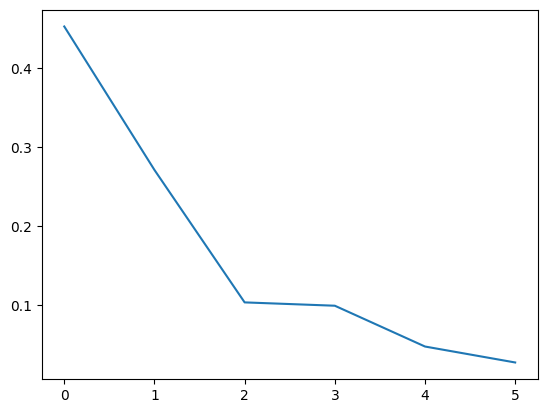

In [12]:
plt.plot(pca_box_cox.explained_variance_ratio_)

In [13]:
pca = PCA(2)
pca.fit(Z_bc_rmo)

PCA(n_components=2)

In [14]:
np.random.seed(42)
sample = Z_bc_rmo.sample(3)

In [15]:
customer_pca_df = pd.DataFrame(pca.transform(Z_bc_rmo), 
                               columns=['Dim 1', 'Dim 2'],
                               index=Z_bc_rmo.index)
sample_pca_df = pd.DataFrame(pca.transform(sample), 
                             columns=['Dim 1', 'Dim 2'],
                             index=sample.index)

<Axes: title={'center': 'PCA transformed Data'}>

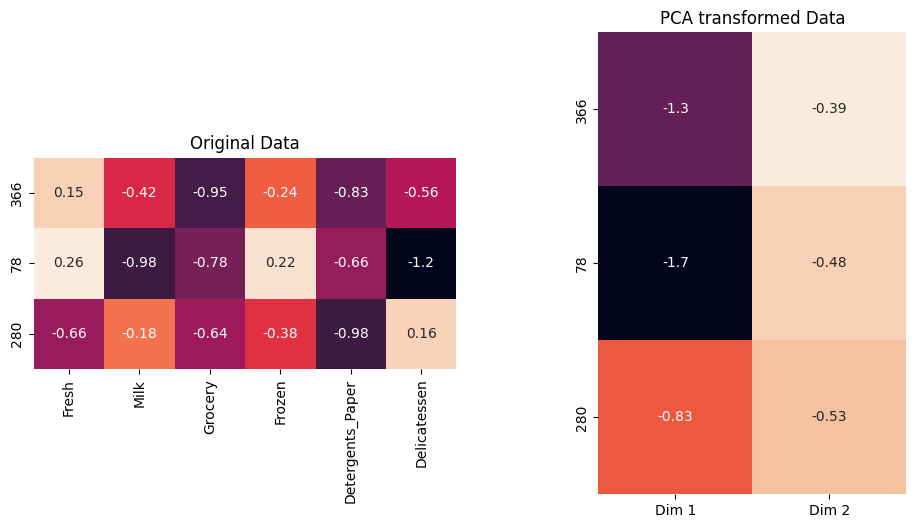

In [16]:
fig = plt.figure(figsize=(12,6))
fig.add_subplot(121)
plt.title("Original Data")
sns.heatmap(sample, annot=True, cbar=False, square=True)
fig.add_subplot(122)
plt.title("PCA transformed Data")
sns.heatmap(sample_pca_df, annot=True, cbar=False, square=True)

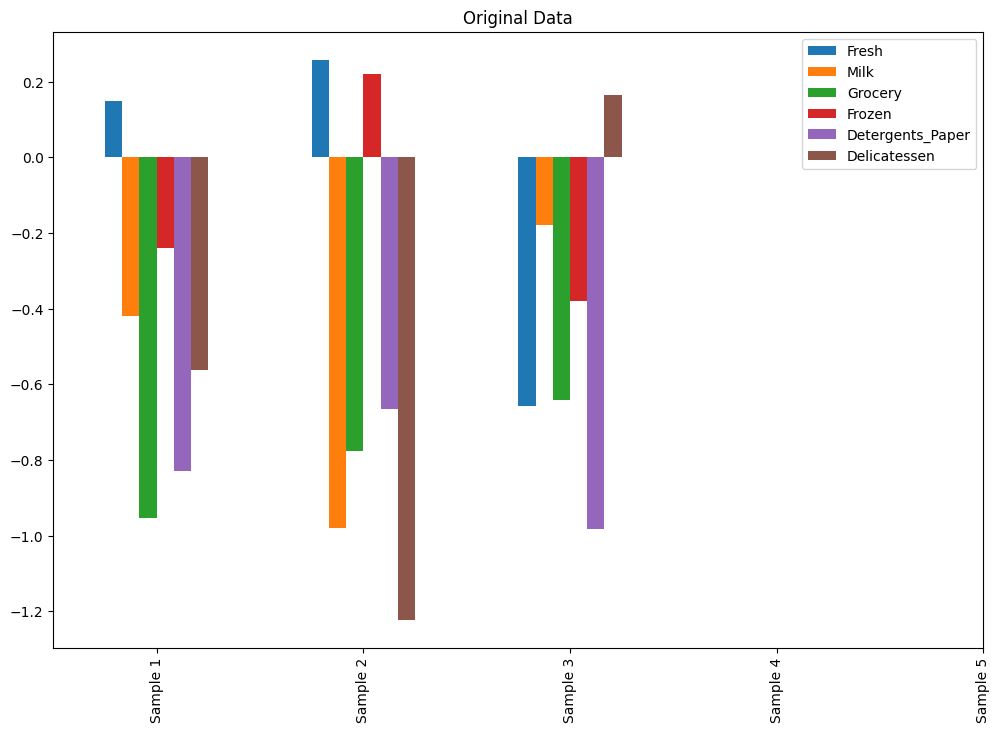

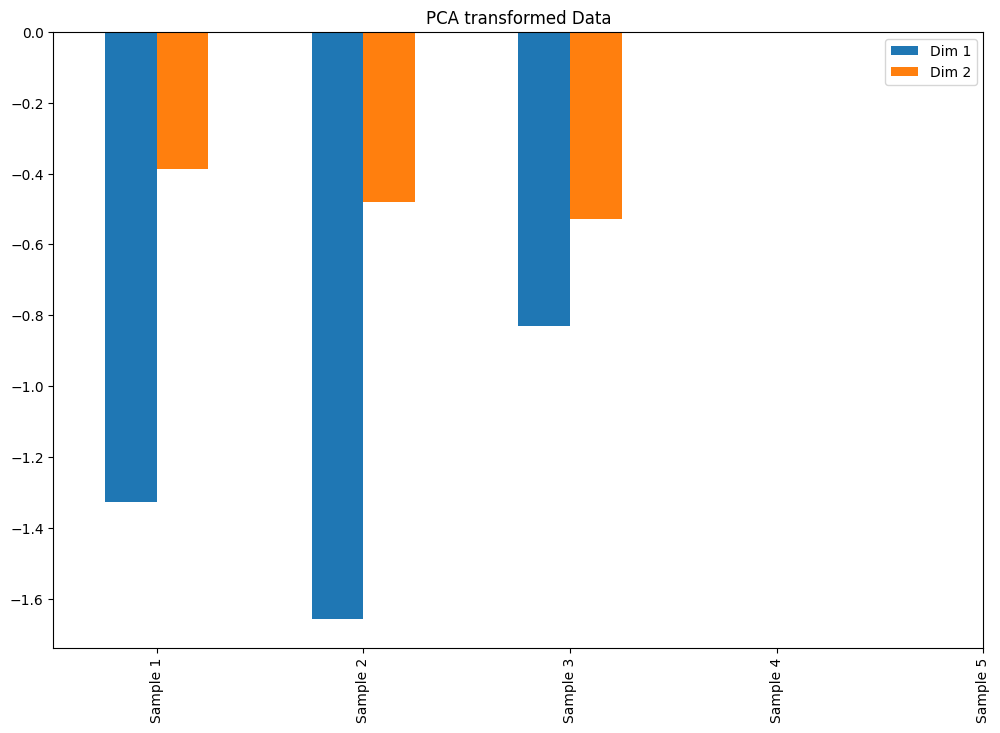

In [17]:
sample.plot(kind='bar', figsize=(12,8))
plt.title("Original Data")
_ = plt.xticks(range(5),['Sample 1','Sample 2','Sample 3', 'Sample 4','Sample 5'])

sample_pca_df.plot(kind='bar', figsize=(12,8))
plt.title("PCA transformed Data")
_ = plt.xticks(range(5),['Sample 1','Sample 2','Sample 3', 'Sample 4','Sample 5'])

<Axes: xlabel='Dim 1', ylabel='Dim 2'>

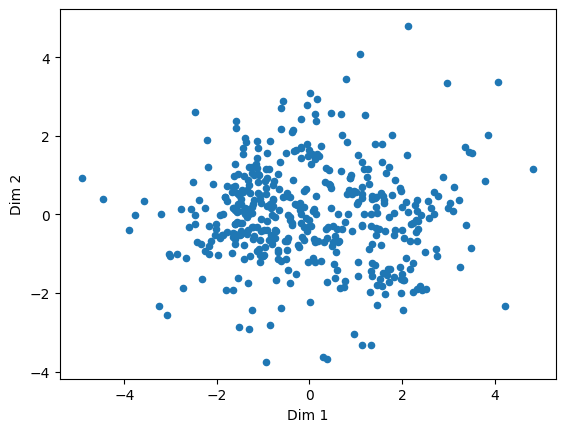

In [18]:
customer_pca_df.plot(x='Dim 1', y='Dim 2', kind='scatter')